# LEGAL IMPRINT WAW Open Search Hackathon TUTORIAL

## Setup
 For this tutorial we use the Legal Imprint Dataset from the OpenWebSearch.eu project

The data, originally stored in parquet files, is converted into a duckdb for easier data handling.
We also use a preprocessed data sample for our geospatial analysis.


#### PYTHON SETUP
We also provide a requirements.txt with all the necessary Python packages. With that, you can create a conda/mamba environment for the tutorial:

In [ ]:
mamba create -n waw_os_legal_imprint python=3.10  # mamba/conda depending on what you use
mamba activate waw_os_legal_imprint
pip install -r requirements.txt

# in jupyter install the required packages
!pip install pandas geopandas duckdb mapclassify

## Data Source

We use the [German Imprints Dataset](https://openwebindex.eu/corpora/4057d6a0-0bd9-11f1-89ba-02a47ca5d9fd) for this tutorial. This is a large-scale collection of websites annotated with the thematic allocation of the website and the geolocation of the extracted address of the imprint website. For the extraction of the topics and addresses the details an LLM pipeline was used. This dataset is provided in parquet format including the URL, html information of the main page, about page and imprint page. The total data set is 47.8 GB of data containing 106 parquet files. In this tutorial today we provide a sample data set.

## Data Extraction with DuckDB
For a better data handling in this tutorial, we use [DuckDB](https://duckdb.org/) to read the parquet files, filter the data and extract relevant information in a preferred data format. At the end, we create a duckdb file with the relevant data for this tutorial. In this tutorial we use the python DuckDB package. The integration of the DuckDB client through the command line is also an option.

Load the following libraries

In [1]:
import duckdb
import pandas as pd
import geopandas as gpd
import os
import mapclassify
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
# In case you are not in the module 3 folder
# navigate to the data folder
print(os.getcwd())
# if needed
#os.chdir("./module3_web_imprint_dataset")

C:\conda_envs\wawopensearch3_hackathon\module3_web_imprint_dataset


A DuckDB connection has to be established. It is connected to the duckdb file containing the original parquet files.

In [3]:
# create the connection to the persistent database
con = duckdb.connect('data/legal_imprints_db_sample.duckdb')

# duckdb  database overview
# Query the list of tables
tables = con.execute("SHOW TABLES").fetchall()

# Print table names
for table in tables:
    print(table)

# print data representation example
con.sql("""SELECT address FROM imprints_all_sample LIMIT 1""")

('imprints_all_sample',)
('imprints_final',)
('imprints_with_coords',)
('imprints_with_domain',)


┌─────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                                                 address                                                 │
│   struct(country varchar, housenumber varchar, postalcode varchar, streetname varchar, town varchar)    │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ {'country': Österreich, 'housenumber': 5A, 'postalcode': 1020, 'streetname': Praterstern, 'town': Wien} │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────┘

In [4]:
# Get an overview of the TABLE
con.execute("PRAGMA table_info(imprints_all_sample)").fetchdf()

,cid,name,type,notnull,dflt_value,pk
0,0,host,VARCHAR,False,None,False
1,1,topic,VARCHAR,False,None,False
2,2,coords,STRUCT(features STRUCT(geometry STRUCT(coordin...,False,None,False
3,3,address,"STRUCT(country VARCHAR, housenumber VARCHAR, p...",False,None,False
4,4,region,"STRUCT(country VARCHAR, county VARCHAR, distri...",False,None,False


In [5]:
# Get the number of entries
row_count = con.execute("SELECT COUNT(*) FROM imprints_all_sample").fetchone()[0]
print(f"Total rows: {row_count}")

Total rows: 100000


## Data Filtering examples

In [12]:
# Filter the original data
con.sql("""
CREATE TABLE imprints_with_coords AS SELECT
    host, topic, address, region,
    TRY(JSON_EXTRACT(address, 'country'))::VARCHAR as address_country,
    TRY(JSON_EXTRACT(address, 'housenumber'))::VARCHAR as address_housenumber,
    TRY(JSON_EXTRACT(address, 'postalcode'))::VARCHAR as address_postalcode,
    TRY(JSON_EXTRACT(address, 'streetname'))::VARCHAR as address_streetname,
    TRY(JSON_EXTRACT(address, 'town'))::VARCHAR as address_town,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.osm_value'))::VARCHAR as osm_value,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.type'))::VARCHAR as osm_type,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.name'))::VARCHAR as osm_name,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.osm_id'))::VARCHAR as osm_id,
    TRY(JSON_EXTRACT(coords, '$.features[0].geometry.coordinates[0]'))::DOUBLE as longitude,
    TRY(JSON_EXTRACT(coords, '$.features[0].geometry.coordinates[1]'))::DOUBLE as latitude,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.city'))::VARCHAR as osm_city,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.country'))::VARCHAR as osm_country,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.county'))::VARCHAR as osm_county,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.district'))::VARCHAR as osm_district,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.housenumber'))::VARCHAR as osm_housenumber,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.street'))::VARCHAR as osm_street,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.postcode'))::VARCHAR as osm_postcode,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.state'))::VARCHAR as osm_state
FROM imprints_all_sample
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [13]:
# Print the overview of this new created table 
con.execute("PRAGMA table_info(imprints_with_coords)").fetchdf()

,cid,name,type,notnull,dflt_value,pk
0,0,host,VARCHAR,False,None,False
1,1,topic,VARCHAR,False,None,False
2,2,address,"STRUCT(country VARCHAR, housenumber VARCHAR, p...",False,None,False
3,3,region,"STRUCT(country VARCHAR, county VARCHAR, distri...",False,None,False
4,4,address_country,VARCHAR,False,None,False
5,5,address_housenumber,VARCHAR,False,None,False
6,6,address_postalcode,VARCHAR,False,None,False
7,7,address_streetname,VARCHAR,False,None,False
8,8,address_town,VARCHAR,False,None,False
9,9,osm_value,VARCHAR,False,None,False


In [14]:
# Print the first row for an overview
con.sql("""SELECT * FROM imprints_with_coords LIMIT 1""")

┌──────────────┬─────────────────────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────┬─────────────────┬─────────────────────┬────────────────────┬────────────────────┬──────────────┬───────────┬──────────┬───────────────┬────────────┬────────────┬────────────┬──────────┬──────────────┬────────────┬───────────────────┬─────────────────┬───────────────┬──────────────┬───────────┐
│     host     │          topic          │                                                 address                                                 │                                     region                                     │ address_country │ address_housenumber │ address_postalcode │ address_streetname │ address_town │ osm_value │ osm_type │   osm_name    │   osm_id   │ longitude  │  latitude  │ osm_city │ osm_country  │ osm_county │   osm_district    │ osm_housenu

In [15]:
# In this case we focus only on entries where the lat and lon and address and topic information is given
con.sql("""
CREATE TABLE imprints_final AS
SELECT *
FROM imprints_with_coords
WHERE
  latitude IS NOT NULL
  AND longitude IS NOT NULL
  AND address IS NOT NULL
  AND topic IS NOT NULL
""")

In [16]:
# Print the first row for an overview
con.sql("""SELECT * FROM imprints_final LIMIT 1""")

┌──────────────┬─────────────────────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────┬─────────────────┬─────────────────────┬────────────────────┬────────────────────┬──────────────┬───────────┬──────────┬───────────────┬────────────┬────────────┬────────────┬──────────┬──────────────┬────────────┬───────────────────┬─────────────────┬───────────────┬──────────────┬───────────┐
│     host     │          topic          │                                                 address                                                 │                                     region                                     │ address_country │ address_housenumber │ address_postalcode │ address_streetname │ address_town │ osm_value │ osm_type │   osm_name    │   osm_id   │ longitude  │  latitude  │ osm_city │ osm_country  │ osm_county │   osm_district    │ osm_housenu

In [17]:
# We also want to extract the domains of the website to potentially use it as a filtering column
con.sql("""
CREATE TABLE imprints_with_domain AS
SELECT
  *,
  REGEXP_EXTRACT(host, '\.([a-zA-Z]{2,})$', 1) as domain
FROM imprints_final
""")

In [18]:
# Print the first row for an overview
con.sql("""SELECT * FROM imprints_with_domain LIMIT 1""")

┌──────────────┬─────────────────────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────┬─────────────────┬─────────────────────┬────────────────────┬────────────────────┬──────────────┬───────────┬──────────┬───────────────┬────────────┬────────────┬────────────┬──────────┬──────────────┬────────────┬───────────────────┬─────────────────┬───────────────┬──────────────┬───────────┬─────────┐
│     host     │          topic          │                                                 address                                                 │                                     region                                     │ address_country │ address_housenumber │ address_postalcode │ address_streetname │ address_town │ osm_value │ osm_type │   osm_name    │   osm_id   │ longitude  │  latitude  │ osm_city │ osm_country  │ osm_county │   osm_district    │ o

## Data Saving
1. Convert the data into a pandas dataframe for further analysis
2. Save the filtered data as a csv file for further analysis in a GIS System or just for storage

In [19]:
# 1. Create pandas Dataframe
df = con.sql("SELECT * FROM imprints_with_domain").fetchdf()
print(df.head())

# 2. Save to csv
con.sql("COPY imprints_with_coords TO 'data_output/imprints_with_coords.csv' (HEADER, DELIMITER ',')")

                    host                            topic  \
0           www.flucc.at          Allgemeine Unterhaltung   
1           jay-knopf.eu  Möbel- und Einrichtungsgeschäft   
2             alabon.com              Unternehmensberater   
3  lilis-fellstueberl.at            Haustierpflegeservice   
4   www.muellerbbm-pm.de               Unternehmensdienst   

                                             address  \
0  {'country': 'Österreich', 'housenumber': '5A',...   
1  {'country': 'Germany', 'housenumber': '206-206...   
2  {'country': 'Deutschland', 'housenumber': '35'...   
3  {'country': 'Austria', 'housenumber': '5A', 'p...   
4  {'country': 'Deutschland', 'housenumber': '1 -...   

                                              region address_country  \
0  {'country': 'Austria', 'county': 'Austria', 'd...    "Österreich"   
1  {'country': 'Germany', 'county': 'Mülheim an d...       "Germany"   
2  {'country': 'Germany', 'county': 'Städteregion...   "Deutschland"   
3  {'cou

In [4]:
# Close the connection
con.close()

## Data filtering
 In order to use the data we need to proprocess and change some data formats.

In [5]:
 # create the connection to the persistent database
con = duckdb.connect('data/imprints_sample_500k.duckdb')

# duckdb  database overview
# Query the list of tables
tables = con.execute("SHOW TABLES").fetchall()

# Print table names
for table in tables:
    print(table)

print(con.sql("""SELECT * FROM imprints_all_hackathon_sample LIMIT 1"""))

('imprints_all_hackathon_sample',)
┌──────────────────────────────┬──────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────┬───────────┬──────────┬──────────┬───────────┬────────────┬─────────────┬───────────────┬───────────────┬──────────────────────┬──────────────┬─────────────────┬───────────────────┬──────────────┬─────────────────────┬─────────┐
│             host             │            topic             │                                                           address                                                            │                                                region                                                 │  osm_key   │ osm_value │ osm_type │ osm_name │  osm_id   │ longitude  │  latitude   │   osm_city    │  osm_country  │      osm_county 

In [6]:
 # Some data / table description
# Count the number of rows
result = con.execute(f"SELECT COUNT(*) FROM imprints_all_hackathon_sample").fetchone()
# Print the count
print(f"Number of entries in imprints_all_hackathon_sample: {result[0]}")

Number of entries in imprints_all_hackathon_sample: 500000


In [7]:
# Get table schema info
schema = con.execute(f"PRAGMA table_info(imprints_all_hackathon_sample)").fetchall()
# Print number of columns
print(f"Number of columns in 'imprints_all_hackathon_sample': {len(schema)}")

# print names 
print("\nColumn details:")
print("-" * 40)
for col in schema:
    col_name = col[1]  # Column name
    col_type = col[2]  # Data type
    print(f"{col_name:<20} | {col_type}")

Number of columns in 'imprints_all_hackathon_sample': 20

Column details:
----------------------------------------
host                 | VARCHAR
topic                | VARCHAR
address              | STRUCT(country VARCHAR, housenumber VARCHAR, postalcode VARCHAR, streetname VARCHAR, town VARCHAR)
region               | STRUCT(country VARCHAR, county VARCHAR, district VARCHAR, state VARCHAR)
osm_key              | VARCHAR
osm_value            | VARCHAR
osm_type             | VARCHAR
osm_name             | VARCHAR
osm_id               | VARCHAR
longitude            | DOUBLE
latitude             | DOUBLE
osm_city             | VARCHAR
osm_country          | VARCHAR
osm_county           | VARCHAR
osm_district         | VARCHAR
osm_housenumber      | VARCHAR
osm_street           | VARCHAR
osm_postcode         | VARCHAR
osm_state            | VARCHAR
domain               | VARCHAR


In [8]:
# Count nulls per column, to identify missing data issues
con.execute("""
    SELECT 
        'address' AS column,
        COUNT(*) AS total_rows,
        COUNT(CASE WHEN address IS NULL THEN 1 END) AS null_count,
        ROUND(COUNT(CASE WHEN address IS NULL THEN 1 END) * 100.0 / COUNT(*), 2) AS null_pct
    FROM imprints_all_hackathon_sample
""").fetchall()

[('address', 500000, 0, 0.0)]

In [9]:
#  Top N Most Frequent Values (for Categorical Columns) it topics 
con.execute("""
SELECT 
        topic,
        COUNT(*) AS frequency
    FROM imprints_all_hackathon_sample
    WHERE topic IS NOT NULL  -- Optional: exclude nulls
    GROUP BY topic
    ORDER BY frequency DESC
    LIMIT 10
""").fetchall()

[('Gesundheits- und Schönheitsservice', 15419),
 ('Geschäfts- und professionelle Dienstleistungen', 14153),
 ('Sportverein', 11589),
 ('Unterkunft', 9549),
 ('Unternehmensdienst', 9407),
 ('Kunstgalerie', 8592),
 ('Veranstaltungsort für darstellende Künste', 8267),
 ('Gemeinnützige Organisation', 8136),
 ('Musikveranstaltungsort', 7843),
 ('Gemeinschaft und Regierung', 7808)]

In [10]:
# From now on we convert the data into a dataframe in order to analyze the data
df = con.sql("SELECT * FROM imprints_all_hackathon_sample").fetchdf()

In [11]:
# close the connection 
con.close()

In [12]:
# OTHER OPTION, IF YOU PREFER: Load tge 
## Load the data as csv file
df = pd.read_csv("./data/germany_imprint_cleaned_hackathon_sample.csv")

In [13]:
### First: add the topic dictionary / classification to add the parent class
topic_dic = pd.read_json("data/topic_categories_dirctionary.jsonl", lines=True)

In [14]:
# Get an overview of the dictionary
print(topic_dic)

                       name                  parent
0    Kunst und Unterhaltung  Kunst und Unterhaltung
1           Vergnügungspark  Kunst und Unterhaltung
2                Attraktion  Kunst und Unterhaltung
3                  Aquarium  Kunst und Unterhaltung
4              Kunstgalerie  Kunst und Unterhaltung
..                      ...                     ...
791                Buslinie    Reisen und Transport
792                    Taxi    Reisen und Transport
793               Reisebüro    Reisen und Transport
794             Reiselounge    Reisen und Transport
795              Truck Stop    Reisen und Transport

[796 rows x 2 columns]


In [15]:
# The oroginal German Legal Imprint dataset contains detailled topic classes. We want to add aparent class system
# merge parent class to df
merged_data = pd.merge(
    df,
    topic_dic[['name', 'parent']],
    left_on='topic',
    right_on='name',
    how='left'
).drop(columns=['name'])

In [16]:
# Apply a check to the column address to convert the string into a readable dictionary
def safe_literal_eval(x):
    if isinstance(x, str):
        try:
            return literal_eval(x)
        except (SyntaxError, ValueError):
            return x
    return x

merged_data["address"] = merged_data["address"].apply(safe_literal_eval)

In [18]:
# get the address statistics and extract information as columns
merged_data['country'] = merged_data['address'].apply(lambda x: x.get('country') if isinstance(x, dict) else None)
merged_data['housenumber'] = merged_data['address'].apply(lambda x: x.get('housenumber') if isinstance(x, dict) else None)
merged_data['postalcode'] = merged_data['address'].apply(lambda x: x.get('postalcode') if isinstance(x, dict) else None)
merged_data['streetname'] = merged_data['address'].apply(lambda x: x.get('streetname') if isinstance(x, dict) else None)
merged_data['town'] = merged_data['address'].apply(lambda x: x.get('town') if isinstance(x, dict) else None)
merged_data.head()

,Unnamed: 0,host,topic,address,region,osm_key,osm_value,osm_type,osm_name,osm_id,...,osm_street,osm_postcode,osm_state,domain,parent,country,housenumber,postalcode,streetname,town
0,0,www.naturheilkunde-riedig.de,Klinik für Alternativmedizin,"{'country': 'Deutschland', 'housenumber': '23'...","{'country': 'Germany', 'county': 'Rhein-Neckar...","""building""","""yes""","""house""",NaN,244974673,...,"""Zehntbergstraße""","""69198""","""Baden-Württemberg""",de,Gesundheit und Medizin,Deutschland,23,69198,Zehntbergstr.,Schriesheim-Altenbach
1,1,optiker-lueneburg.de,Optiker,"{'country': 'Deutschland', 'housenumber': '4-6...","{'country': 'Germany', 'county': 'Lüneburg', '...","""building""","""retail""","""house""",NaN,117103284,...,"""Käthe-Krüger-Straße""","""21337""","""Niedersachsen""",de,Gesundheit und Medizin,Deutschland,4-6,21337,Käthe-Krüger-Str.,Lüneburg
2,2,photo.marcusschram.de,Fotograf,"{'country': 'Deutschland', 'housenumber': '', ...","{'country': 'Germany', 'county': 'Erlangen-Höc...","""landuse""","""industrial""","""locality""","""Klärwerk Kalchreuth""",29730830,...,NaN,"""90562""","""Bayern""",de,Geschäfts- und professionelle Dienstleistungen,Deutschland,,90562,,Kalchreuth
3,3,mavex-pumpen.de,Lieferant von Industrieausrüstung,"{'country': 'Deutschland', 'housenumber': '45'...","{'country': 'Germany', 'county': 'Mannheim', '...","""place""","""house""","""house""",NaN,12304615834,...,"""Uhlandstraße""","""68167""","""Baden-Württemberg""",de,Geschäfts- und professionelle Dienstleistungen,Deutschland,45,68167,Käfertalerstraße,Mannheim
4,4,www.tennisplatz-beregnung.de,Geschäfts- und professionelle Dienstleistungen,"{'country': 'Deutschland', 'housenumber': '38'...","{'country': 'Germany', 'county': 'Steinfurt', ...","""place""","""house""","""house""",NaN,2528407935,...,"""Prozessionsweg""","""48493""","""Nordrhein-Westfalen""",de,Geschäfts- und professionelle Dienstleistungen,Deutschland,38,48493,Prozessionsweg,Wettringen


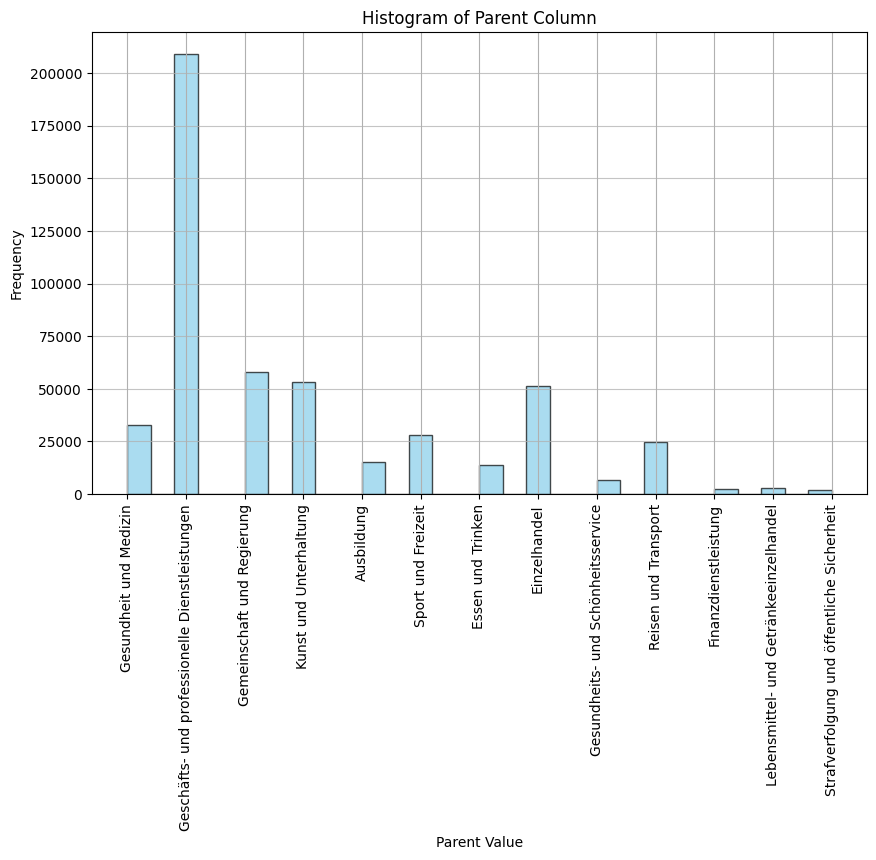

In [19]:
# statistics of parent class distribution of data, domain distributions, group by region
plt.figure(figsize=(10, 6))
merged_data['parent'].hist(bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Histogram of Parent Column')
plt.xlabel('Parent Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=90)
plt.show()

## Geospatial Analysis

In this spatial analysis we want to spatially analyze our dataset. The locations are based on the lat/lon coordinates the [Photon geocoder](https://github.com/komoot/photon) linked to the address extracted with the LLM pipeline. Right now the data is not spatially filtered. In order to spatially clip the data points, to be independent on the string versions of Germany, we spatially clip the points with a Vector layer of Germany. Therefore, we use the administrative vector layers [Verwaltungsgebiete 1:250 000](https://gdz.bkg.bund.de/index.php/default/verwaltungsgebiete-1-250-000-stand-31-12-vg250-31-12.html) from [Bundesamt für Kartographie und Geodäsie](https://gdz.bkg.bund.de/index.php/default/digitale-geodaten.html).
We use this dataset for further spatial analysis and the distribution of the main classes in the county. This is then used to aggregate the point information to district level and integrate population and district size to compare class distribution.

#### Enviornment:
We currently use Python and geospatial packages for this example analysis. If you wish, you can also export the data and use this dataset in a GIS like QGIS

In [20]:
# Load the Germany counties dataset
germany_counties = gpd.read_file('data/VG250_KRS.shp')

<Axes: >

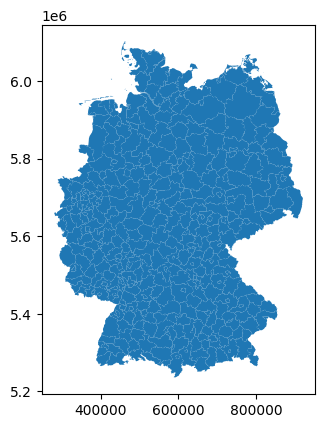

In [21]:
germany_counties.plot(markersize=2)

In [22]:
# convert data into a geodataframe and save it as a geojson
# Our data conatins latitude and longitude data we first load the geodataframe with EPSG 4326 (WGS84) coordinate system
# For further analysis and comparison the data then can for example be reprjected to the same UTM Coordinate system like the administrative data of Germany.
imprint = gpd.GeoDataFrame(merged_data, geometry=gpd.points_from_xy(merged_data.longitude, merged_data.latitude), crs="EPSG:4326")

# adjust projection
imprint = imprint.to_crs(germany_counties.crs)

# test the projection, it should be EPSG:25832
print(imprint.crs)

# Clip points to Germany
imprint_ger = gpd.clip(imprint, germany_counties)

EPSG:25832


<Axes: >

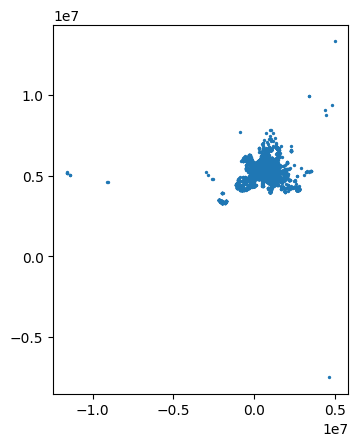

In [23]:
# Viszualize the points from the sample dataset
imprint.plot(markersize=2)

<Axes: >

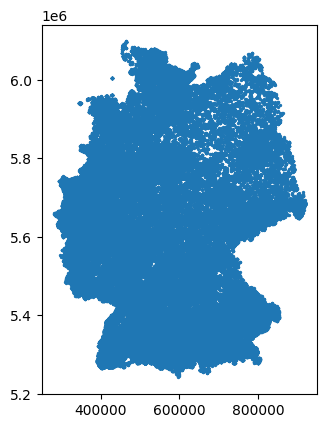

In [24]:
# Viszualize the points clopped to GErmany
imprint_ger.plot(markersize=2)

In [25]:
# Count points in poylgon to get the number of points from the dataset in each county
#Spatially join the data
spatial_join = gpd.sjoin(imprint_ger, germany_counties, how='left', predicate='within')

# Count the points within each polygon
point_counts = spatial_join.groupby('index_right').size().rename('point_count_all')

# Merge the information together
counties_gdf = germany_counties.merge(
    point_counts,
    left_index=True,
    right_index=True,
    how='left'
)
print(counties_gdf.head())

              OBJID     BEGINN  ADE  GF  BSG    ARS    AGS       SDV_ARS  \
0  DEBKGVG200000C75 2021-12-02    4   4    1  01001  01001  010010000000   
1  DEBKGVG200000C76 2021-11-30    4   4    1  01002  01002  010020000000   
2  DEBKGVG200000C77 2021-06-24    4   4    1  01003  01003  010030000000   
3  DEBKGVG200000C78 2021-08-24    4   4    1  01004  01004  010040000000   
4  DEBKGVG200000C79 2021-11-17    4   4    1  01051  01051  010510044044   

            GEN               BEZ  ...  FK_S3   NUTS         ARS_0     AGS_0  \
0     Flensburg  Kreisfreie Stadt  ...      R  DEF01  010010000000  01001000   
1          Kiel  Kreisfreie Stadt  ...      R  DEF02  010020000000  01002000   
2        Lübeck  Kreisfreie Stadt  ...      R  DEF03  010030000000  01003000   
3    Neumünster  Kreisfreie Stadt  ...      R  DEF04  010040000000  01004000   
4  Dithmarschen             Kreis  ...      R  DEF05  010510000000  01051000   

         WSK     EWZ      KFL            DLM_ID  \
0 2008-01-0

<Axes: >

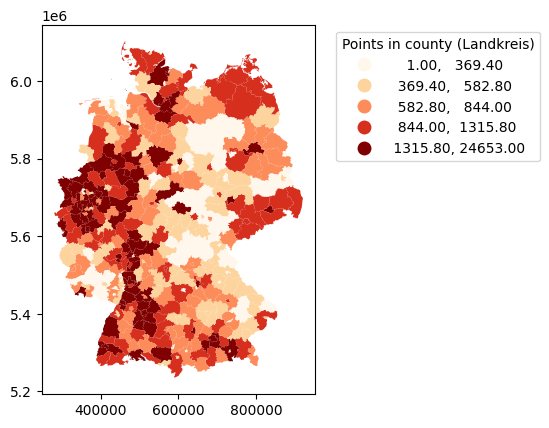

In [27]:
# Vizualize the absolute points per county (Landkreis)
counties_gdf.plot(column='point_count_all',
                  cmap='OrRd',
                  scheme='quantiles',
                  legend=True,
                  legend_kwds={"title": "Points in county (Landkreis)", "bbox_to_anchor": (1.05, 1), "loc": "upper left" })

In [49]:
# Count points in polygon divided by the parent classes
spatial_join = gpd.sjoin(imprint_ger, germany_counties, how='left', predicate='within')
grouped_classes = spatial_join.groupby(['index_right', 'parent']).size().rename('point_count').unstack(fill_value=0)
counties_gdf_classes = germany_counties.merge(
    grouped_classes,
    left_index=True,
    right_index=True,
    how='left'
)
print(counties_gdf_classes.head())

              OBJID     BEGINN  ADE  GF  BSG    ARS    AGS       SDV_ARS  \
0  DEBKGVG200000C75 2021-12-02    4   4    1  01001  01001  010010000000   
1  DEBKGVG200000C76 2021-11-30    4   4    1  01002  01002  010020000000   
2  DEBKGVG200000C77 2021-06-24    4   4    1  01003  01003  010030000000   
3  DEBKGVG200000C78 2021-08-24    4   4    1  01004  01004  010040000000   
4  DEBKGVG200000C79 2021-11-17    4   4    1  01051  01051  010510044044   

            GEN               BEZ  ...  Finanzdienstleistung  \
0     Flensburg  Kreisfreie Stadt  ...                   2.0   
1          Kiel  Kreisfreie Stadt  ...                  10.0   
2        Lübeck  Kreisfreie Stadt  ...                   5.0   
3    Neumünster  Kreisfreie Stadt  ...                   4.0   
4  Dithmarschen             Kreis  ...                   1.0   

  Gemeinschaft und Regierung Geschäfts- und professionelle Dienstleistungen  \
0                       65.0                                          184.0   


<Axes: >

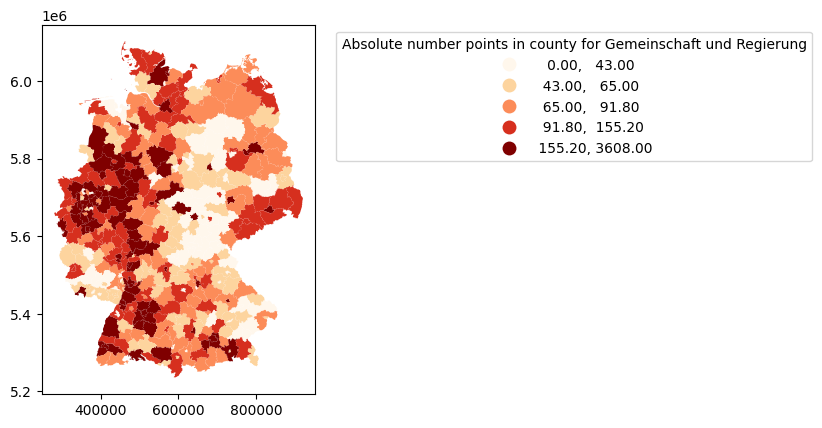

In [29]:
# Vizualize a specific class
counties_gdf_classes.plot(column='Gemeinschaft und Regierung',
                  cmap='OrRd',
                  scheme='quantiles',
                  legend=True,
                  legend_kwds={"title": "Absolute number points in county for Gemeinschaft und Regierung", "bbox_to_anchor": (1.05, 1), "loc": "upper left" })

In [30]:
# Find the max class of the classes per county
counties_gdf_classes['max_class'] = grouped.idxmax(axis=1)

# Find the actual maximum count value
counties_gdf_classes['max_val'] = grouped.max(axis=1)
# if nothing has been found:
counties_gdf_classes['max_class'] = counties_gdf_classes['max_class'].fillna('No Points')
counties_gdf_classes['max_val'] = counties_gdf_classes['max_val'].fillna(0).astype(int)

<Axes: >

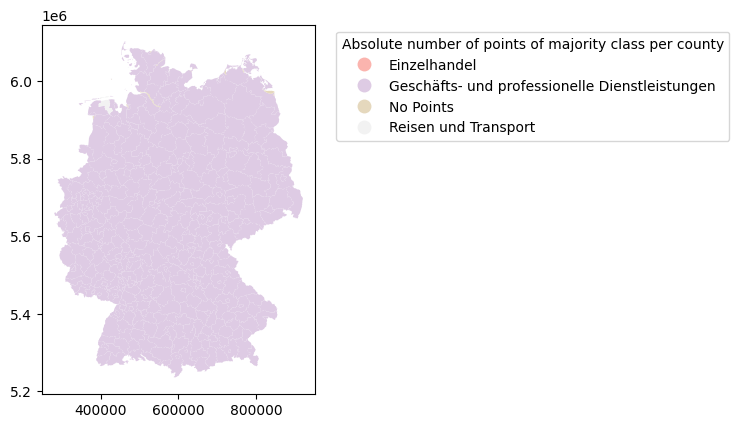

In [31]:
# Vizualize a specific class
counties_gdf_classes.plot(column='max_class',
                  cmap='Pastel1',
                  legend=True,
                  legend_kwds={"title": "Absolute number of points of majority class per county", "bbox_to_anchor": (1.05, 1), "loc": "upper left" })

<Axes: >

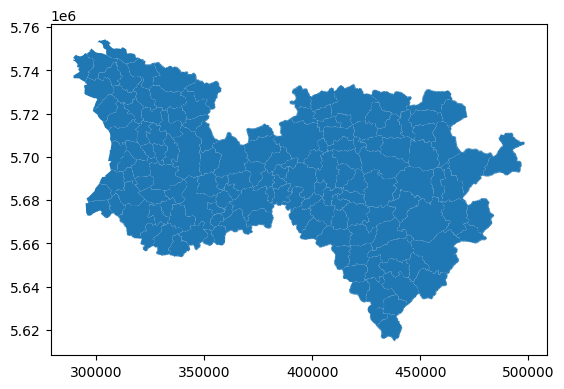

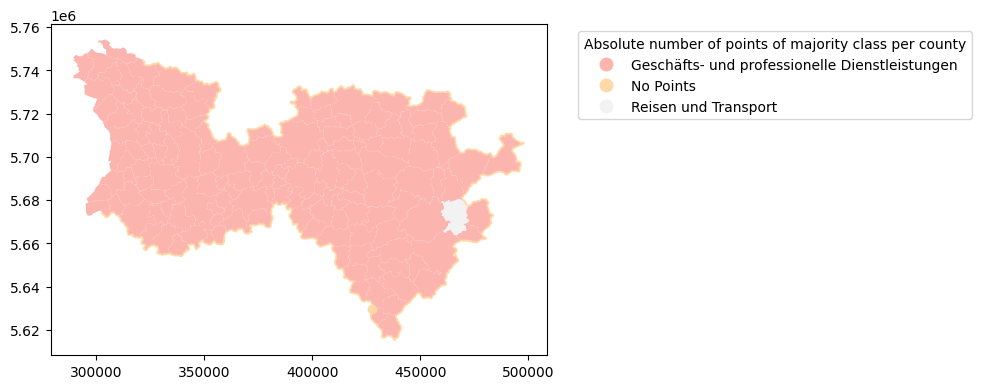

In [32]:
## Example on a spatially smaller level

# Load the municiplaities for the Ruhrgebiet
munici = gpd.read_file("data/VG250_GEM.shp")

# load the Regierungsbezirk and filter for two
rbz = gpd.read_file("data/VG250_RBZ.shp")

# filter
rbz_sel = rbz[(rbz['GEN'] == 'Arnsberg') | (rbz['GEN'] == 'Düsseldorf')]

# clip municiplaities with the regierungsbezir area
munici_clip = gpd.clip(munici, rbz_sel)

munici_clip.plot()

# count points in the counties
spatial_join = gpd.sjoin(imprint_ger, munici_clip, how='left', predicate='within')
grouped = spatial_join.groupby(['index_right', 'parent']).size().rename('point_count').unstack(fill_value=0)
counties_gdf_sel = munici_clip.merge(
    grouped,
    left_index=True,
    right_index=True,
    how='left'
)
# Find the actual maximum count value
counties_gdf_sel['max_class'] = grouped.idxmax(axis=1)
counties_gdf_sel['max_val'] = grouped.max(axis=1)
# if nothing has been found:
counties_gdf_sel['max_class'] = counties_gdf_sel['max_class'].fillna('No Points')
counties_gdf_sel['max_val'] = counties_gdf_sel['max_val'].fillna(0).astype(int)

# Vizualize a specific class
counties_gdf_sel.plot(column='max_class',
                  cmap='Pastel1',
                  legend=True,
                  legend_kwds={"title": "Absolute number of points of majority class per county", "bbox_to_anchor": (1.05, 1), "loc": "upper left" })

In [33]:
#Plot the dataframe
counties_gdf_sel

,OBJID,BEGINN,ADE,GF,BSG,ARS,AGS,SDV_ARS,GEN,BEZ,...,Geschäfts- und professionelle Dienstleistungen,Gesundheit und Medizin,Gesundheits- und Schönheitsservice,Kunst und Unterhaltung,Lebensmittel- und Getränkeeinzelhandel,Reisen und Transport,Sport und Freizeit,Strafverfolgung und öffentliche Sicherheit,max_class,max_val
2859.0,DEBKGVG20000027L,2020-10-08,6,4,1,066350002002,06635002,066350002002,Bad Arolsen,Stadt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Points,0
2865.0,DEBKGVG20000027R,2021-07-29,6,4,1,066350008008,06635008,066350008008,Diemelstadt,Stadt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Points,0
2349.0,DEBKGVG2000001TH,2021-11-18,6,4,1,057620036036,05762036,057620036036,Warburg,Stadt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Points,0
2720.0,DEBKGVG20000023Q,2020-10-08,6,4,1,065340004004,06534004,065340004004,Biedenkopf,Stadt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Points,0
2871.0,DEBKGVG20000027X,2019-04-09,6,4,1,066350014014,06635014,066350014014,Hatzfeld (Eder),Stadt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Points,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2462.0,DEBKGVG2000001WM,2020-11-24,6,4,1,059780008008,05978008,059780008008,Bönen,Gemeinde,...,21.0,5.0,0.0,4.0,0.0,1.0,3.0,0.0,Geschäfts- und professionelle Dienstleistungen,21
2308.0,DEBKGVG2000001SC,2020-11-18,6,4,1,055700016016,05570016,055700016016,Drensteinfurt,Stadt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Points,0
2459.0,DEBKGVG2000001WJ,2020-11-24,6,4,1,059740052052,05974052,059740052052,Werl,Stadt,...,46.0,11.0,1.0,8.0,2.0,6.0,12.0,0.0,Geschäfts- und professionelle Dienstleistungen,46
2391.0,DEBKGVG2000001UN,2020-11-18,6,4,1,059150000000,05915000,059150000000,Hamm,Stadt,...,233.0,33.0,17.0,41.0,4.0,11.0,30.0,0.0,Geschäfts- und professionelle Dienstleistungen,233


## DIY

Not it is your turn. Play around with certain filtering parameters, filtering for specific areas and topics and use the data for your scientific research question.
 Some suggestions:
   * Maybe you want to analyze a different study area?
   * Adjust the visualization and color scheme? [color scheme optioins](https://de.matplotlib.net/stable/tutorials/colors/colormaps.html)
   * Create a bivariate map of the population and data imprints?
   * Compare specific topics and their distribution?
   * You can also integrate your own (geospatial) data and synergistically analyze the data products
     Alternative:
        * When you are familiar with QGIS you can export the data (e.g. as a geopackage file and viszualize the data there (e.g. with pie charts of class distributions of the topics per county)

## During the WAW

During the WAW the grouped discussed further option of vizualizations and aggregation
Only the absolute number of entries distorts the presentation, as we have different sizes of districts and also different numbers of people in the district. 
The latter information of the number of people in the district, are responsible to create an imprint website on the net. Therefore a normalization of the absolute number of points in regards to the pouplation number or the area size. These information is given in the administrative data layers.

In [34]:
# Calculate the normalized number of points per citizens per 1000 capita
counties_gdf['points_ewz'] = counties_gdf['point_count_all'] / counties_gdf['EWZ'] * 1000

C:\conda_envs\waw_os_legal_imprint\lib\site-packages\mapclassify\classifiers.py:940: RuntimeWarning: invalid value encountered in subtract
  css = yc - yc.mean()
C:\conda_envs\waw_os_legal_imprint\lib\site-packages\mapclassify\classifiers.py:970: RuntimeWarning: invalid value encountered in scalar divide
  gadf = 1 if adam == 0 else 1 - self.adcm / adam


<Axes: >

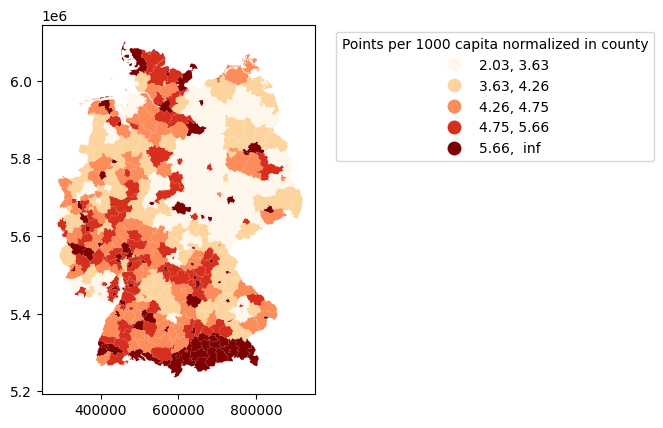

In [35]:
# Vizualize the normalized points
counties_gdf.plot(column='points_ewz',
                  cmap='OrRd',
                  scheme='quantiles',
                  legend=True,
                  legend_kwds={"title": "Points per 1000 capita normalized in county", "bbox_to_anchor": (1.05, 1), "loc": "upper left" })

In [37]:
# Calculate points per 1000 capita for a specific class
counties_gdf_classes['reisen_ewz'] = counties_gdf_classes['Reisen und Transport'] / counties_gdf_classes['EWZ'] * 1000

C:\conda_envs\waw_os_legal_imprint\lib\site-packages\mapclassify\classifiers.py:940: RuntimeWarning: invalid value encountered in subtract
  css = yc - yc.mean()
C:\conda_envs\waw_os_legal_imprint\lib\site-packages\mapclassify\classifiers.py:970: RuntimeWarning: invalid value encountered in scalar divide
  gadf = 1 if adam == 0 else 1 - self.adcm / adam


<Axes: >

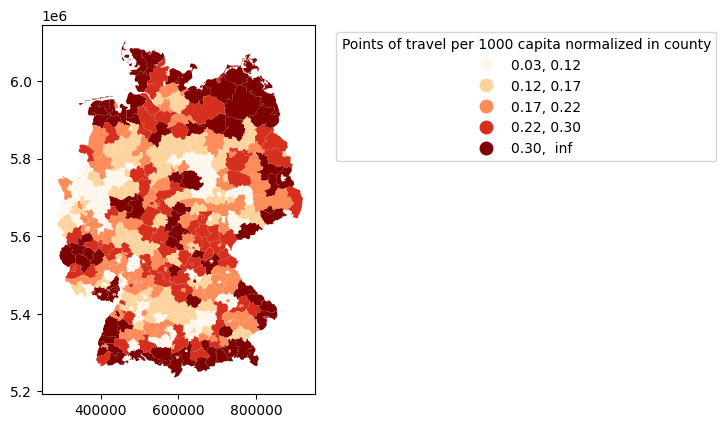

In [38]:
counties_gdf_classes.plot(column='reisen_ewz',
                  cmap='OrRd',
                  scheme='quantiles',
                  legend=True,
                  legend_kwds={"title": "Points of travel per 1000 capita normalized in county", "bbox_to_anchor": (1.05, 1), "loc": "upper left" })

In [52]:
for col in grouped_classes.columns:
    # Skip if no data
    if col not in counties_gdf_classes.columns:
        continue

    # Per capita: points per person
    counties_gdf_classes[f'{col} per capita'] = counties_gdf_classes[col] / counties_gdf_classes['EWZ'] * 1000

    # Per km²: points per square kilometer
    #counties_gdf[f'{col}_per_km2'] = counties_gdf[col] / counties_gdf['area_km2']

# Optional: Round for readability
counties_gdf_classes = counties_gdf_classes.round(4)  # Round to 4 decimal places

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# rename list of classes 
grouped_classes = ['Ausbildung per capita', 'Einzelhandel per capita', 'Essen und Trinken per capita', 'Finanzdienstleistung per capita',
    'Gemeinschaft und Regierung per capita','Geschäfts- und professionelle Dienstleistungen per capita', 'Gesundheit und Medizin per capita',
    'Gesundheits- und Schönheitsservice per capita', 'Kunst und Unterhaltung per capita', 'Lebensmittel- und Getränkeeinzelhandel per capita',
    'Reisen und Transport per capita', 'Sport und Freizeit per capita', 'Strafverfolgung und öffentliche Sicherheit per capita']

# Apply a function for all classes in parallel, set up the plot grids
n_cols = 5
n_rows = int(np.ceil(len(grouped_classes) / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(24, 18), constrained_layout=True)

for i, colname in enumerate(grouped_classes):
    row = i // n_cols
    col = i % n_cols
    
    # plot the classes
    counties_gdf_classes.plot(column=colname,
                      cmap='OrRd',
                      scheme='quantiles',
                      legend=False,  # Keine separate Legende mehr
                      ax=axs[row, col],
                     )
    
    # add specific titles
    axs[row, col].set_title(f"{colname}", fontsize=9, pad=8, fontweight='bold')

# hide empty subplots
for i in range(len(grouped_classes), n_rows * n_cols):
    row = i // n_cols
    col = i % n_cols
    axs[row, col].axis('off')

# unified legend
sm = plt.cm.ScalarMappable(cmap='OrRd', 
                           norm=plt.Normalize(vmin=0, vmax=1))  # Werte anpassen!
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs, shrink=0.8, pad=0.02, aspect=20)
cbar.set_label('Points per 1,000 people', fontsize=10)

# Optional: Add a title to the whole figure
fig.suptitle('Points per Capita by Category', fontsize=16, fontweight='bold', y=0.98)


plt.savefig('./data_output/karte_per_capita_gruppe.png', dpi=300, bbox_inches='tight')
plt.show()

C:\conda_envs\waw_os_legal_imprint\lib\site-packages\mapclassify\classifiers.py:940: RuntimeWarning: invalid value encountered in subtract
  css = yc - yc.mean()
C:\conda_envs\waw_os_legal_imprint\lib\site-packages\mapclassify\classifiers.py:970: RuntimeWarning: invalid value encountered in scalar divide
  gadf = 1 if adam == 0 else 1 - self.adcm / adam
C:\conda_envs\waw_os_legal_imprint\lib\site-packages\mapclassify\classifiers.py:940: RuntimeWarning: invalid value encountered in subtract
  css = yc - yc.mean()
C:\conda_envs\waw_os_legal_imprint\lib\site-packages\mapclassify\classifiers.py:970: RuntimeWarning: invalid value encountered in scalar divide
  gadf = 1 if adam == 0 else 1 - self.adcm / adam
C:\conda_envs\waw_os_legal_imprint\lib\site-packages\mapclassify\classifiers.py:940: RuntimeWarning: invalid value encountered in subtract
  css = yc - yc.mean()
C:\conda_envs\waw_os_legal_imprint\lib\site-packages\mapclassify\classifiers.py:970: RuntimeWarning: invalid value encountered